## 1. Анализ Premium-сегмента (Индивидуальные тренировки)
Цель: Оценка финансовой ценности и демографии клиентов, предпочитающих персональные занятия.

Сегментация пользователей (доля индивидуальных тренировок >70%).

Расчет юнит-экономики сегмента: вычисление среднего чека и частоты покупок.

Поиск демографических инсайтов (распределение по полу и городам).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data.csv')
df.head(3)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female


In [41]:
new_df=df.groupby('id_user').agg({'cnt_indiv':'sum','cnt_total':'sum',}).reset_index()
new_df['indiv_pros70']=new_df['cnt_indiv']/new_df['cnt_total']*100
new_df=new_df[new_df['indiv_pros70']>=70][['id_user','indiv_pros70']]

In [48]:
user_list=new_df['id_user'].tolist()


In [74]:
df_sp=df[df['id_user'].isin(user_list)]

ex1=df_sp.groupby(['city','gender']).agg(avg_check=('sum_total','mean'),avg_tren=('cnt_total','mean')).reset_index()
ex1.head()        

,city,gender,avg_check,avg_tren
0,Екатеринбург,female,5911.538462,3.307692
1,Екатеринбург,male,5566.101695,3.118644
2,Казань,female,6545.454545,3.954545
3,Казань,male,5796.078431,3.254902
4,Москва,female,5623.829787,3.170213


## 2. Профилирование Power Users (Топ-клиенты)
Цель: Выявление ядра лояльной аудитории для программ удержания.

Агрегация общего числа посещений за весь период.

Выделение топ-10 самых активных клиентов (Power Users).

Анализ демографического профиля лояльного сегмента.

In [89]:
df2=df.groupby('id_user').agg({'cnt_total':'sum'}).reset_index().sort_values('cnt_total',ascending = False ).head(10)
list_top10=ex2['id_user'].tolist()
list_top10

[1381, 1013, 1657, 1506, 1929, 1570, 1001, 1002, 1194, 1582]

In [94]:
ex2=df[df['id_user'].isin(list_top10)]
ex2.head

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
9,1001,2023-01,12,2,9600,3600,14,13200,2023-01,2023-12,Москва,35.0,female
10,1001,2023-02,11,3,8800,5400,14,14200,2023-01,2023-12,Москва,35.0,female
11,1001,2023-03,8,6,6400,10800,14,17200,2023-01,2023-12,Москва,35.0,female
12,1001,2023-04,9,5,7200,9000,14,16200,2023-01,2023-12,Москва,35.0,female
13,1001,2023-05,3,7,2400,11200,10,13600,2023-01,2023-12,Москва,35.0,female


In [96]:
ex2[['city','gender']].value_counts()

city          gender
Москва        female    33
              male      33
Екатеринбург  male      19
СПб           female    12
              male      10
Name: count, dtype: int64

## 3. Динамика клиентской базы (Когортный анализ: Retention & Churn)
Цель: Оценка здоровья продукта — мониторинг притока и оттока пользователей по месяцам.

Когортное разделение базы на новые (New), активные (Active) и ушедшие (Churned) когорты.

Построение сводных витрин по месяцам.

Визуализация динамики изменения клиентской базы (линейный график трендов).

In [97]:
df.head() 

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female
3,1000,2023-06,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
4,1000,2023-07,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female


In [116]:

df_min=df[df['mon']==df['min_mon']].groupby(['mon']).agg(cnt_user_min=('id_user', 'nunique')).reset_index()
################
df_max=df[df['mon']==df['max_mon']].groupby('mon').agg(cnt_user_max=('id_user','nunique')).reset_index()
################
df_act=df.groupby('mon').agg(cnt_user_act=('id_user', 'nunique')).reset_index()

In [113]:
df_min.head(5)

,mon,cnt_user
0,2023-01,337
1,2023-02,88
2,2023-03,83
3,2023-04,62
4,2023-05,57


In [118]:
all_df=df_act.merge(df_min,on='mon',how='left')\
             .merge(df_max,on='mon',how ='left')
all_df.head()

,mon,cnt_user_act,cnt_user_min,cnt_user_max
0,2023-01,337,337,15
1,2023-02,350,88,22
2,2023-03,355,83,37
3,2023-04,345,62,21
4,2023-05,360,57,21


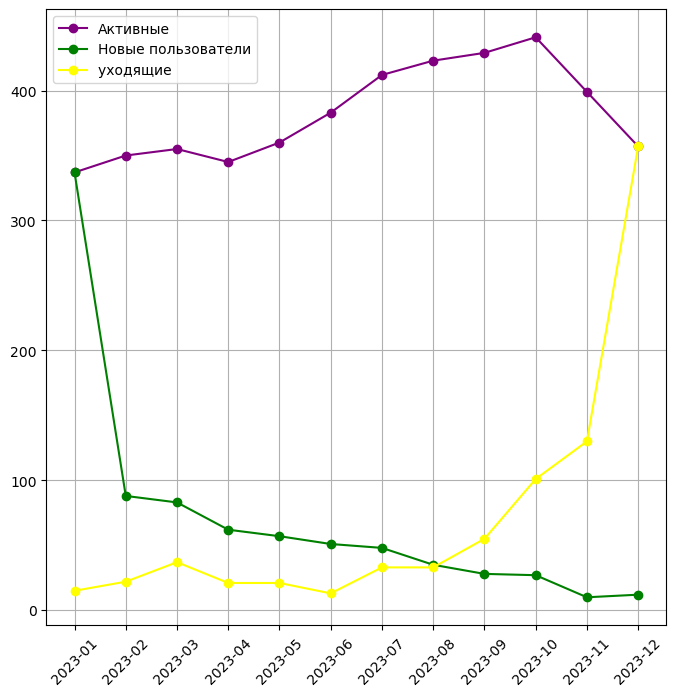

In [132]:
plt.figure(figsize=(8,8))
plt.plot(all_df['mon'],all_df['cnt_user_act'],label='Активные',marker='o',color='purple')
plt.plot(all_df['mon'],all_df['cnt_user_min'],label= 'Новые пользователи',marker='o',color='green')
plt.plot(all_df['mon'],all_df['cnt_user_max'],label= 'уходящие ',marker='o',color='Yellow')
plt.xlabel=('Месяц')
plt.ylabel=('Количество')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()
